In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics  import mean_squared_error, r2_score

In [10]:
#load dataset
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [16]:
#select one feature
X=data[['AveRooms']].values
Y=data['Price'].values

In [17]:
# split data
X_train,X_test,Y_train,Y_test=train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [26]:
#feature scaling
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [52]:
w = 0
b = 0
learning_rate = 0.01
epochs = 1000

cost_history = []

n = len(X_train_scaled)

for i in range(epochs):
    Y_pred = w * X_train_scaled.flatten() + b

    # Compute cost
    cost = (1/(2*n)) * np.sum((Y_pred - Y_train)**2)
    cost_history.append(cost)

    dw = (1/n) * np.sum((Y_pred - Y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(Y_pred - Y_train)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost={cost:.4f}")

Y_pred_gd = w * X_test_scaled.flatten() + b


Epoch 0, Cost=2.8149
Epoch 100, Cost=0.9414
Epoch 200, Cost=0.6904
Epoch 300, Cost=0.6568
Epoch 400, Cost=0.6523
Epoch 500, Cost=0.6517
Epoch 600, Cost=0.6516
Epoch 700, Cost=0.6516
Epoch 800, Cost=0.6516
Epoch 900, Cost=0.6516


In [47]:
print("Gradient Descent")
print("----------------")
print("weight:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(Y_test,Y_pred_gd))
print("R2 SCore:",r2_score(Y_test,Y_pred_gd))

Gradient Descent
----------------
weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 SCore: 0.013798228607320828


In [48]:
X_train_ne=np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]
theta=np.linalg.inv(X_train_ne.T @ X_train_ne)@ X_train_ne.T @ Y_train
Y_pred_ne=X_test_ne @ theta

In [53]:
print("\nNormal Equation")
print("----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(Y_test,Y_pred_ne))
print("R2 SCore:",r2_score(Y_test,Y_pred_ne))


Normal Equation
----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 SCore: 0.013795337532284901


<function matplotlib.pyplot.show(close=None, block=None)>

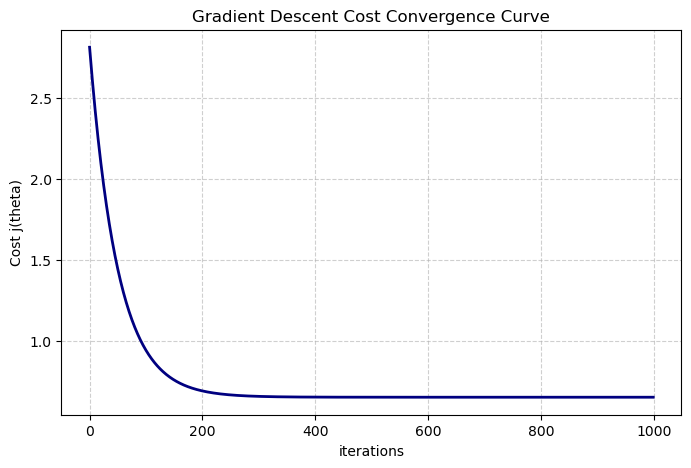

In [55]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('iterations')
plt.ylabel('Cost j(theta)')
plt.grid(True, linestyle='--',alpha=0.6)
plt.show

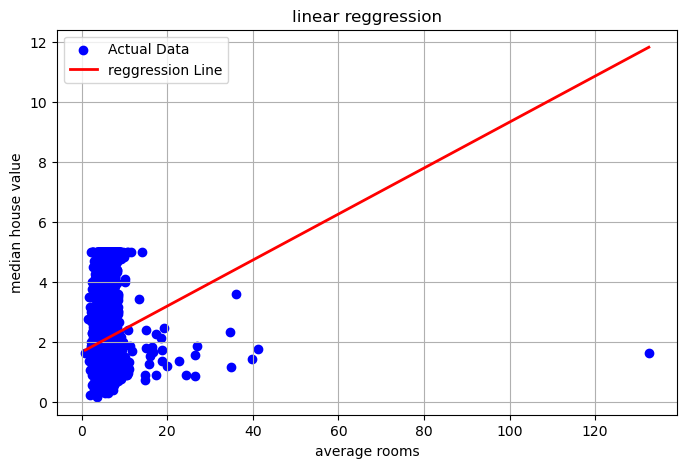

In [59]:
index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,Y_test,color='blue',label='Actual Data')
plt.plot(
    X_test.flatten()[index],
    Y_pred_ne[index],
    color='red',
    linewidth=2,
    label='reggression Line'
)
plt.title("linear reggression")
plt.xlabel("average rooms")
plt.ylabel("median house value")
plt.legend()
plt.grid(True)

plt.show()
    